## Tratamiento de datos para la regresión.

Para el entrenamiento de los modelos de regresión necesitamos obtener variables dependientes de las ventas por fecha. En este caso diarias. El resto de datos no aportan demasiado valor. Por lo tanto vamos a realizar lo siguiente:

- Cargar el csv ya limpio para la regresión.

- Prescindir de las variables que no sean necesarias.

- Tipar correctamente las columnas que sean necesarias.

- Generar nuevas variables que aporten información sobre las ventas diarias.

#### Librerías utilizadas.

Las librerías utilizadas para el tratamiento de datos y la regresión son las siguientes:

- Pandas: para la manipulación de datos.
- Sklearn: para la regresión y el preprocesamiento de datos.

In [199]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

#### Carga del csv limpio y visualización.

Carga del csv limpio para la regresión y visualización de las primeras filas para comprobar que se ha cargado correctamente.

In [200]:
df = pd.read_csv('../output/data_limpio_regresion.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 476888 entries, 0 to 476887
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    476888 non-null  int64  
 1   StockCode    476888 non-null  str    
 2   Description  476888 non-null  str    
 3   Quantity     476888 non-null  int64  
 4   InvoiceDate  476888 non-null  str    
 5   UnitPrice    476888 non-null  float64
 6   CustomerID   355996 non-null  float64
 7   Country      476888 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 29.1 MB


In [201]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED RETROSPOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,12/1/2010 8:34,2.10,13047.0,United Kingdom


#### Variables necesarias.

Las columnas necesarias para entrenar los modelos de regresión son las siguientes, teniendo en cuenta que se busca predecir las ventas diarias:

- InvoiceDate: Para agrupar los valores por día.

- Quantity: Apoyo para obtener las ganancias totales por día.

- UnitPrice: Apoyo para obtener las ganancias totales por día.

Por lo tanto se elimina el resto de columnas para que no ensucien el nuevo dataset.

In [202]:
df_transformado = df.copy()
df_transformado = df_transformado[['InvoiceDate', 'Quantity', 'UnitPrice']]
df_transformado.head(5)

,InvoiceDate,Quantity,UnitPrice
0,12/1/2010 8:26,6,2.55
1,12/1/2010 8:26,6,3.39
2,12/1/2010 8:26,8,2.75
3,12/1/2010 8:26,6,3.39
4,12/1/2010 8:26,6,3.39


#### Tipado de las columnas.

Tanto Quantity como UnitPrice están bien tipadas. Pero el caso de InvoiceDate es diferente ya que está en formato String. Para poder trabajar correctamente hay que pasar esta columna a formato Fecha.

In [203]:
df_transformado['InvoiceDate'] = pd.to_datetime(df_transformado['InvoiceDate'], format='%m/%d/%Y %H:%M')
df_transformado.info()
df_transformado.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 476888 entries, 0 to 476887
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceDate  476888 non-null  datetime64[us]
 1   Quantity     476888 non-null  int64         
 2   UnitPrice    476888 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 10.9 MB


,InvoiceDate,Quantity,UnitPrice
0,2010-12-01 08:26:00,6,2.55
1,2010-12-01 08:26:00,6,3.39
2,2010-12-01 08:26:00,8,2.75
3,2010-12-01 08:26:00,6,3.39
4,2010-12-01 08:26:00,6,3.39


#### Creación de nuevas variables.

Esta parte es fundamental para entrenar al modelo de la mejor forma posible. Hay que representar los siguienes patrones con nuevas variables:

- Ganancias totales por día. Es la variable que se busca predecir, por lo tanto es fundamental para el entrenamiento del modelo.

- Ganancias por día de la semana. Como sólo existen datos de un año es irrelevante tomar como referencia el día del año. El día de la semana se repite en muchas ocasiones y puede dar un aproximado real.

- Ganancias por día del mes. Al igual que con las ganancias por día de la semana representa mejor las tendencias dentro de cada mes para intentar aproximar valores.

- Ganancias del día anterior. Es una variable que puede aportar información sobre la tendencia de las ventas, ya que si el día anterior ha habido muchas ventas es posible que el día siguiente también las haya. 

Primero hay que generar un nuevo dataframe agrupado por fechas y añadir una variable de ganancias totales por día.

In [204]:
df_transformado['GananciasVenta'] = df_transformado['Quantity'] * df_transformado['UnitPrice']
df_agrupado = df_transformado.groupby('InvoiceDate').agg({'GananciasVenta': 'sum'}).reset_index()
df_agrupado.rename(columns={'GananciasVenta': 'GananciasTotales'}, inplace=True)

df_agrupado['GananciasTotales'] = df_agrupado['GananciasTotales'].round(2)
df_agrupado.head(5)

,InvoiceDate,GananciasTotales
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,294.70
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,737.66


Ahora hay que compactar todas las ganancias en días únicos, quedando de la siguiente forma:

In [205]:
df_transformado['InvoiceDate'] = df_transformado['InvoiceDate'].dt.date
df_agrupado = df_transformado.groupby('InvoiceDate').agg({'GananciasVenta': 'sum'}).reset_index()
df_agrupado.rename(columns={'GananciasVenta': 'GananciasTotales'}, inplace=True)
df_agrupado['GananciasTotales'] = df_agrupado['GananciasTotales'].round(2)
df_agrupado.head(5)

,InvoiceDate,GananciasTotales
0,2010-12-01,31052.61
1,2010-12-02,26292.13
2,2010-12-03,25490.33
3,2010-12-05,23445.96
4,2010-12-06,36394.80


Para mejorar los datos, es necesario crear las nuevas variables que indiquen el día de la semana y el día del mes.

In [206]:
df_agrupado['DiaSemana'] = pd.to_datetime(df_agrupado['InvoiceDate']).dt.dayofweek
df_agrupado['DiaMes'] = pd.to_datetime(df_agrupado['InvoiceDate']).dt.day
df_agrupado.head()

,InvoiceDate,GananciasTotales,DiaSemana,DiaMes
0,2010-12-01,31052.61,2,1
1,2010-12-02,26292.13,3,2
2,2010-12-03,25490.33,4,3
3,2010-12-05,23445.96,6,5
4,2010-12-06,36394.80,0,6


Para capturar patrones temporales recientes se pueden añadir lags (valores anteriores) de las ganancias totales. Como los primeros valores no tienen lags anteriores, los rellenamos con la media de las ganancias totales. El objetivo es añadir a cada fila las ganancias del día anterior, para capturar la tendencia de las ventas.

In [207]:
df_agrupado['Lag_1_Ventas'] = df_agrupado['GananciasTotales'].shift(1)
df_agrupado = df_agrupado.dropna(subset=['Lag_1_Ventas']).reset_index(drop=True)

df_agrupado.head(10)

,InvoiceDate,GananciasTotales,DiaSemana,DiaMes,Lag_1_Ventas
0,2010-12-02,26292.13,3,2,31052.61
1,2010-12-03,25490.33,4,3,26292.13
2,2010-12-05,23445.96,6,5,25490.33
3,2010-12-06,36394.80,0,6,23445.96
4,2010-12-07,32279.50,1,7,36394.80
5,2010-12-08,30884.51,2,8,32279.50
6,2010-12-09,32488.87,3,9,30884.51
7,2010-12-10,30289.15,4,10,32488.87
8,2010-12-12,11549.95,6,12,30289.15
9,2010-12-13,25636.59,0,13,11549.95


Ahora hay que borrar los datos iniciales que ya no son necesarios como el Quatity y UnitPrice, y convertir en variables categóricas el día de la semana.

In [208]:
dias_semana = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']

df_agrupado['DiaSemana'] = df_agrupado['DiaSemana'].apply(lambda x: dias_semana[x])
df_agrupado.head(5)

,InvoiceDate,GananciasTotales,DiaSemana,DiaMes,Lag_1_Ventas
0,2010-12-02,26292.13,Jueves,2,31052.61
1,2010-12-03,25490.33,Viernes,3,26292.13
2,2010-12-05,23445.96,Domingo,5,25490.33
3,2010-12-06,36394.80,Lunes,6,23445.96
4,2010-12-07,32279.50,Martes,7,36394.80


#### Comprobación de los nuevos valores.

Visualizamos las características de ganancias totales para comprobar que no existen valores extraños.

In [209]:
df_agrupado.describe()

,GananciasTotales,DiaMes,Lag_1_Ventas
count,304.000000,304.000000,304.000000
mean,19139.677533,15.184211,19178.705066
std,8591.415264,8.625253,8618.541431
min,2728.960000,1.000000,2728.960000
25%,13532.805000,8.000000,13532.805000
50%,17719.150000,15.000000,17719.150000
75%,23207.155000,22.000000,23372.842500
max,52609.460000,31.000000,52609.460000


#### Eliminado de outliers.

Como en todos los análisis es importante eliminar los outliers para que no ensucien el entrenamiento del modelo. Se eliminan alrededor de un 4% de los datos.

Estadísticas de GananciasTotales:
  Q1 (25%):        13532.81€
  Q3 (75%):        23207.15€
  IQR:             9674.35€
  Límite inferior: -978.72€
  Límite superior: 37718.68€


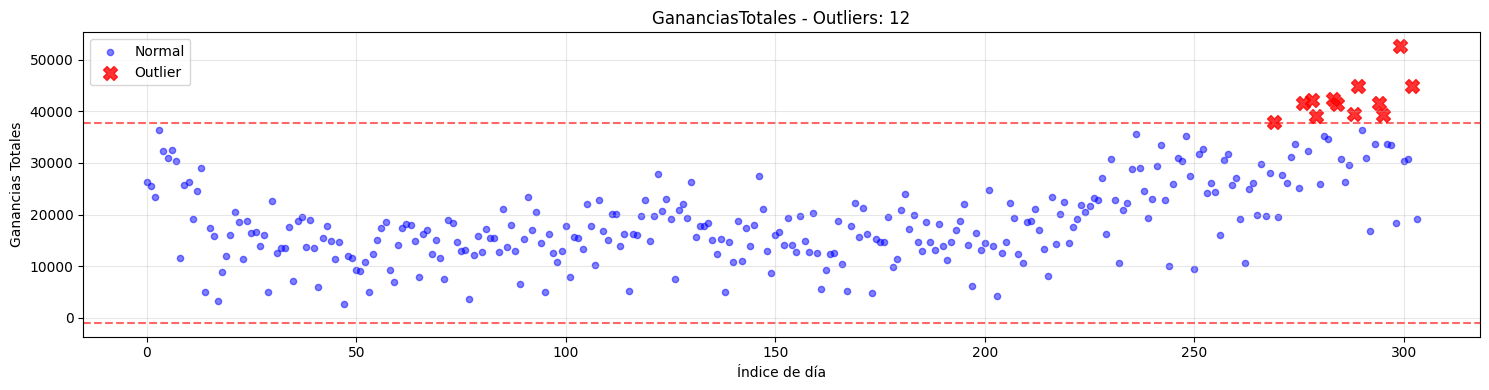

In [210]:
import numpy as np

Q1 = df_agrupado['GananciasTotales'].quantile(0.25)
Q3 = df_agrupado['GananciasTotales'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Estadísticas de GananciasTotales:")
print(f"  Q1 (25%):        {Q1:.2f}€")
print(f"  Q3 (75%):        {Q3:.2f}€")
print(f"  IQR:             {IQR:.2f}€")
print(f"  Límite inferior: {limite_inferior:.2f}€")
print(f"  Límite superior: {limite_superior:.2f}€")

outliers = (df_agrupado['GananciasTotales'] < limite_inferior) | (df_agrupado['GananciasTotales'] > limite_superior)
num_outliers = outliers.sum()

fig, ax = plt.subplots(figsize=(15, 4))

indices = np.arange(len(df_agrupado))
ax.scatter(indices[~outliers], df_agrupado['GananciasTotales'][~outliers], 
  color='blue', alpha=0.5, s=20, label='Normal')
ax.scatter(indices[outliers], df_agrupado['GananciasTotales'][outliers], 
  color='red', alpha=0.8, s=100, marker='X', label='Outlier')

ax.axhline(limite_inferior, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
ax.axhline(limite_superior, color='red', linestyle='--', linewidth=1.5, alpha=0.6)

ax.set_title(f"GananciasTotales - Outliers: {num_outliers}")
ax.set_xlabel('Índice de día')
ax.set_ylabel('Ganancias Totales')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [211]:
print(f"\nOutliers detectados: {num_outliers} ({num_outliers/len(df_agrupado)*100:.2f}%)")

if num_outliers > 0:
  print("\nValores considerados outliers:")
  
  df_agrupado = df_agrupado[~outliers].reset_index(drop=True)
  print(f"\nDataset después de eliminar outliers: {len(df_agrupado)} filas")
else:
  print("\nNo se detectaron outliers con este criterio")


Outliers detectados: 12 (3.95%)

Valores considerados outliers:

Dataset después de eliminar outliers: 292 filas


#### Preprocesado de variables categóricas.

Para el correcto tratamiento de los días de la semana es necesario aplicar una técnica de preprocesado como OneHotEncoding, que deja los valores en formato de bits y permite una mejor representación de los datos para el modelo.

In [212]:
encoder = OneHotEncoder(sparse_output=False, drop=None)
columnas_categoricas = ['DiaSemana']

df_encoded = pd.DataFrame(encoder.fit_transform(df_agrupado[columnas_categoricas]))
df_encoded.columns = encoder.get_feature_names_out(columnas_categoricas)

df_final = pd.concat([df_agrupado.drop(columns=columnas_categoricas), df_encoded], axis=1)

df_final.head()

,InvoiceDate,GananciasTotales,DiaMes,Lag_1_Ventas,DiaSemana_Domingo,DiaSemana_Jueves,DiaSemana_Lunes,DiaSemana_Martes,DiaSemana_Miercoles,DiaSemana_Viernes
0,2010-12-02,26292.13,2,31052.61,0.0,1.0,0.0,0.0,0.0,0.0
1,2010-12-03,25490.33,3,26292.13,0.0,0.0,0.0,0.0,0.0,1.0
2,2010-12-05,23445.96,5,25490.33,1.0,0.0,0.0,0.0,0.0,0.0
3,2010-12-06,36394.80,6,23445.96,0.0,0.0,1.0,0.0,0.0,0.0
4,2010-12-07,32279.50,7,36394.80,0.0,0.0,0.0,1.0,0.0,0.0


#### Normalización de los datos.

Para mejorar el rendimiento de los modelos de regresión es importante normalizar los datos para suavizar las diferencias de escala entre las variables. Esto se logra utilizando el StandardScaler, que transforma los datos para que tengan media 0 y desviación estándar 1.

In [213]:
scaler = StandardScaler()
columnas_numericas = ['GananciasTotales', 'Lag_1_Ventas']
df_final[columnas_numericas] = scaler.fit_transform(df_final[columnas_numericas])
df_final.head()

,InvoiceDate,GananciasTotales,DiaMes,Lag_1_Ventas,DiaSemana_Domingo,DiaSemana_Jueves,DiaSemana_Lunes,DiaSemana_Martes,DiaSemana_Miercoles,DiaSemana_Viernes
0,2010-12-02,1.111529,2,1.525539,0.0,1.0,0.0,0.0,0.0,0.0
1,2010-12-03,1.001539,3,0.942194,0.0,0.0,0.0,0.0,0.0,1.0
2,2010-12-05,0.721093,5,0.843943,1.0,0.0,0.0,0.0,0.0,0.0
3,2010-12-06,2.497409,6,0.593427,0.0,0.0,1.0,0.0,0.0,0.0
4,2010-12-07,1.932874,7,2.180166,0.0,0.0,0.0,1.0,0.0,0.0


#### Separación en conjuntos de datos para entrenamiento y prueba.

Se realiza el split temporal correcto para entrenar en el futuro a los modelos.:
- Train + Validation: datos del 1 de diciembre 2010 al 8 de noviembre 2011
- Test: datos del 9 de noviembre 2011 al 9 de diciembre 2011
Luego dividimos train en 80% train y 20% validation.

In [214]:
import os

df_final['InvoiceDate'] = pd.to_datetime(df_final['InvoiceDate'])

fecha_split_test = pd.to_datetime('2011-11-09')

df_train_val = df_final[df_final['InvoiceDate'] < fecha_split_test].copy()
df_test = df_final[df_final['InvoiceDate'] >= fecha_split_test].copy()

split_idx = int(len(df_train_val) * 0.8)
df_train = df_train_val.iloc[:split_idx].copy()
df_validation = df_train_val.iloc[split_idx:].copy()

os.makedirs('../output/regresion', exist_ok=True)

df_train_export = df_train.drop(columns=['InvoiceDate'])
df_validation_export = df_validation.drop(columns=['InvoiceDate'])
df_test_export = df_test.drop(columns=['InvoiceDate'])

df_train_export.to_csv('../output/regresion/data_train_regresion.csv', index=False, encoding='ISO-8859-1')
df_validation_export.to_csv('../output/regresion/data_validation_regresion.csv', index=False, encoding='ISO-8859-1')
df_test_export.to_csv('../output/regresion/data_test_regresion.csv', index=False, encoding='ISO-8859-1')

print(f"Train: {len(df_train_export)} filas -> ../output/regresion/data_train_regresion.csv")
print(f"Validation: {len(df_validation_export)} filas -> ../output/regresion/data_validation_regresion.csv")
print(f"Test: {len(df_test_export)} filas -> ../output/regresion/data_test_regresion.csv")

Train: 220 filas -> ../output/regresion/data_train_regresion.csv
Validation: 55 filas -> ../output/regresion/data_validation_regresion.csv
Test: 17 filas -> ../output/regresion/data_test_regresion.csv
